In [ ]:
import pandas as pd
import os
from collections import defaultdict

os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

all_introns = pd.read_table('results/hela_tm_tg_mix/stringtie_viral/merged.splice_sites.with_types.tsv')
nc_introns = all_introns[all_introns['splice_type'] == 'NC']
nc_introns_dict = defaultdict(list)
for idx, row in nc_introns.iterrows():
    nc_introns_dict[f'{row["chr"]}_{row["strand"]}'].append(f'{row["start"]}-{row["end"]}')

all_transcripts = pd.read_table(
    'results/hela_tm_tg_mix/stringtie_viral/merged.transcript_intron_regions.tsv',
    header=None, names=['transcript_id', 'chr', 'strand', 'intron_regions'],
    dtype={'transcript_id': str, 'chr': str, 'strand': str, 'intron_regions': str}
)

# Remove transcripts without intron regions (single-exon transcripts)
all_transcripts.dropna(subset=['intron_regions'], inplace=True)

def check_whether_contains_nc_introns(row):
    for intron_region in row['intron_regions'].split(';'):
        if intron_region in nc_introns_dict[f'{row["chr"]}_{row["strand"]}']:
            return True
    return False

nc_transcripts = all_transcripts[all_transcripts.apply(check_whether_contains_nc_introns, axis=1)]
nc_transcripts.head(10)


,transcript_id,chr,strand,intron_regions
2,MSTRG.2.1,GL000009.2,+,56085-122563
10,MSTRG.8.1,GL000218.1,+,48143-95173
11,MSTRG.8.2,GL000218.1,+,89059-95173
16,MSTRG.13.1,GL000220.1,-,121701-121827
17,MSTRG.13.2,GL000220.1,-,129020-129035
21,MSTRG.17.1,GL000250.2,-,170250-172819;172847-174391;174425-174556;1746...
23,MSTRG.19.1,GL000250.2,+,1319497-1319612;1319767-1320013;1320115-132032...
24,MSTRG.19.2,GL000250.2,+,1319767-1320013;1320115-1320320;1320432-1322764
25,MSTRG.20.1,GL000250.2,-,1319767-1320013;1320115-1320320;1320432-1322764
27,MSTRG.22.1,GL000250.2,-,1325572-1326681;1326791-1327195


In [2]:
import os

os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

nc_transcripts_ids = []
nc_ids_cache = 'results/hela_tm_tg_mix/stringtie_viral/nc_transcripts_ids.txt'
if os.path.exists(nc_ids_cache):
    with open(nc_ids_cache, 'r') as f:
        nc_transcripts_ids = [line.strip() for line in f]
else:
    nc_transcripts_ids = nc_transcripts['transcript_id'].tolist()
    with open(nc_ids_cache, 'w') as f:
        for transcript_id in nc_transcripts_ids:
            f.write(transcript_id + '\n')

print(nc_transcripts_ids[:20])
print(f'Number of transcripts containing NC introns: {len(nc_transcripts_ids)}')

['MSTRG.2.1', 'MSTRG.8.1', 'MSTRG.8.2', 'MSTRG.13.1', 'MSTRG.13.2', 'MSTRG.17.1', 'MSTRG.19.1', 'MSTRG.19.2', 'MSTRG.20.1', 'MSTRG.22.1', 'MSTRG.28.1', 'MSTRG.30.1', 'MSTRG.31.1', 'MSTRG.33.1', 'MSTRG.34.1', 'MSTRG.37.1', 'MSTRG.38.1', 'MSTRG.40.1', 'MSTRG.43.1', 'MSTRG.45.1']
Number of transcripts containing NC introns: 7057


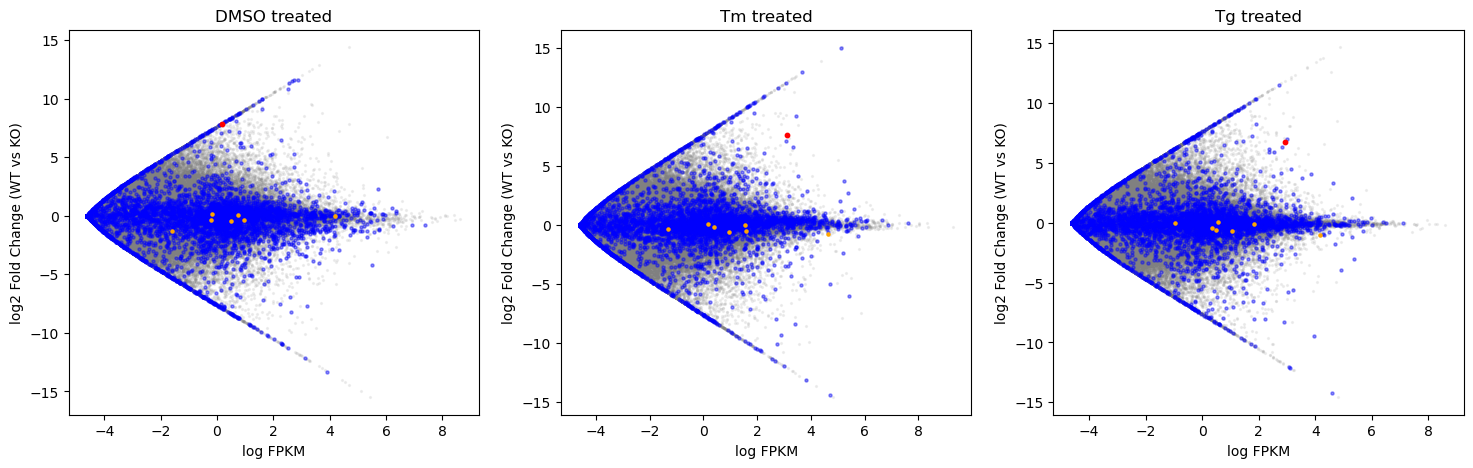

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

samples = ['WT_DMSO', 'KO_DMSO', 'WT_Tm', 'KO_Tm', 'WT_Tg', 'KO_Tg']

stringtie_transcripts = pd.DataFrame()
for i, sample in enumerate(samples):
    if i == 0:
        stringtie_transcripts = pd.read_csv(
            f'results/hela_tm_tg_mix/stringtie_viral/{sample}/t_data.ctab',
            sep='\t', usecols=['chr', 'start', 'end', 't_id', 't_name', 'gene_id', 'FPKM'], index_col='t_id'
        )
        stringtie_transcripts.rename(columns={'FPKM': sample}, inplace=True)
    else:
        tmp_transcripts = pd.read_csv(
            f'results/hela_tm_tg_mix/stringtie_viral/{sample}/t_data.ctab',
            sep='\t', usecols=['t_id', 'FPKM'], index_col='t_id'
        )
        stringtie_transcripts[sample] = tmp_transcripts['FPKM']

for i, experiment in enumerate(['DMSO', 'Tm', 'Tg']):
    stringtie_transcripts[f'{experiment}_fold_change'] = (stringtie_transcripts[f'WT_{experiment}'] + 0.01) / (stringtie_transcripts[f'KO_{experiment}'] + 0.01)
    stringtie_transcripts[f'{experiment}_log2FC'] = np.log2(stringtie_transcripts[f'{experiment}_fold_change'])
    stringtie_transcripts[f'{experiment}_mean_FPKM'] = stringtie_transcripts[[f'WT_{experiment}', f'KO_{experiment}']].mean(axis=1)
    stringtie_transcripts[f'{experiment}_logFPKM'] = stringtie_transcripts[f'{experiment}_mean_FPKM'].apply(lambda x: np.log(x + 0.01))

plt.figure(figsize=(18, 5))

for i, experiment in enumerate(['DMSO', 'Tm', 'Tg']):
    # Filter out transcripts with zero FPKM in both conditions
    # plot_df = plot_df[(plot_df[['WT', 'KO']] != 0).any(axis=1)]

    # MA plot
    plot_df = stringtie_transcripts[[f'{experiment}_logFPKM', f'{experiment}_log2FC', 't_name', 'gene_id']].copy()
    plot_df.columns = ['logFPKM', 'log2FC', 't_name', 'gene_id']
    # highlight some points
    nc_points = plot_df[plot_df['t_name'].isin(nc_transcripts_ids)].copy()
    xbp1_points = plot_df[plot_df['gene_id'] == 'MSTRG.22589'].copy()
    xbp1s_point = plot_df[plot_df['t_name'] == 'ENST00000344347.6'].copy()

    plt.subplot(1, 3, i + 1)
    plt.scatter(plot_df['logFPKM'], plot_df['log2FC'], alpha=0.1, color='gray', s=2)
    plt.scatter(nc_points['logFPKM'], nc_points['log2FC'], alpha=0.4, color='blue', s=5)
    plt.scatter(xbp1_points['logFPKM'], xbp1_points['log2FC'], color='orange', s=5)
    plt.scatter(xbp1s_point['logFPKM'], xbp1s_point['log2FC'], color='red', s=10)
    plt.xlabel('log FPKM')
    plt.ylabel('log2 Fold Change (WT vs KO)')
    plt.title(f'{experiment} treated')

plt.show()


In [14]:
nc_fpkm = stringtie_transcripts[stringtie_transcripts['t_name'].isin(nc_transcripts_ids)].copy()
nc_fpkm = nc_fpkm[nc_fpkm['chr'].str.startswith('chr')]
nc_fpkm = nc_fpkm[nc_fpkm[['DMSO_mean_FPKM', 'Tm_mean_FPKM', 'Tg_mean_FPKM']].sum(axis=1) > 0.1]
nc_fpkm = nc_fpkm[(nc_fpkm['Tm_log2FC'] > 1.5) & (nc_fpkm['Tg_log2FC'] > 1.5)]
nc_fpkm.sort_values(by='Tm_log2FC', inplace=True, ascending=False)

nc_fpkm

,chr,start,end,t_name,gene_id,WT_DMSO,KO_DMSO,WT_Tm,KO_Tm,WT_Tg,...,DMSO_mean_FPKM,DMSO_logFPKM,Tm_fold_change,Tm_log2FC,Tm_mean_FPKM,Tm_logFPKM,Tg_fold_change,Tg_log2FC,Tg_mean_FPKM,Tg_logFPKM
t_id,,,,,,,,,,,,,,,,,,,,,
508193,chrX,72771692,72949140,MSTRG.34503.3,MSTRG.34503,11.181908,5.219661,10.185615,0.000000,7.230561,...,8.200785,2.105448,1019.561500,9.993733,5.092808,1.629791,2.982119,1.576338,4.824276,1.575731
114271,chr12,56639106,56643958,ENST00000547250.5,MSTRG.9214,0.013103,0.199471,3.516369,0.000000,0.138312,...,0.106287,-2.151694,352.636900,8.462040,1.758185,0.569953,14.831200,3.890563,0.069156,-2.536335
10216,chr1,23303879,23344358,MSTRG.2404.2,MSTRG.2404,3.126619,0.000000,3.455952,0.000000,1.635162,...,1.563309,0.453181,346.595200,8.437108,1.727976,0.552721,164.516200,7.362086,0.817581,-0.189248
319234,chr22,28794560,28800597,ENST00000344347.6,MSTRG.22589,2.328406,0.000000,45.187988,0.213173,36.682764,...,1.164203,0.160590,202.524445,7.661952,22.700580,3.122831,107.801313,6.752231,18.506569,2.918666
98195,chr11,120336413,120467308,MSTRG.8133.7,MSTRG.8133,0.001187,0.501211,1.755084,0.000470,1.705096,...,0.251199,-1.342473,168.584909,7.397332,0.877777,-0.119035,134.222570,7.068483,0.853937,-0.146255
305598,chr20,58888859,58911192,ENST00000481039.6,MSTRG.21687,3.071453,2.562324,1.947711,0.001975,1.880625,...,2.816889,1.039177,163.483173,7.352998,0.974843,-0.015273,160.794778,7.329077,0.941191,-0.050040
385759,chr5,61332264,61546172,MSTRG.26624.3,MSTRG.26624,0.195031,1.524270,1.601528,0.000000,0.812276,...,0.859650,-0.139664,161.152800,7.332285,0.800764,-0.209778,82.227600,6.361551,0.406138,-0.876738
505559,chrX,49570402,49577754,MSTRG.34351.3,MSTRG.34351,0.000000,6.340592,2.758607,0.030412,10.118928,...,3.170296,1.156974,68.509527,6.098233,1.394510,0.339688,2.861133,1.516586,6.824554,1.921991
135954,chr13,102848739,102875995,ENST00000651281.1,MSTRG.10636,0.542330,0.436452,0.654514,0.000000,0.826991,...,0.489391,-0.694366,66.451400,6.054228,0.327257,-1.086910,3.321511,1.731840,0.534491,-0.607904
